# Student GPA Prediction — Exploratory Data Analysis

---

## Project Objective

This notebook performs a comprehensive **Exploratory Data Analysis (EDA)** on a dataset of 50,000 university students to understand the factors that influence **Post-Semester GPA**.

The goal of this project is to predict `Post_Semester_GPA` using features related to:
- **Academic background** (prior GPA, major, year of study)
- **GenAI usage behavior** (weekly hours, primary use case, prompt engineering skill)
- **Study habits** (traditional study hours, tool diversity)
- **Psychological factors** (exam anxiety, perceived AI dependency)
- **Institutional context** (AI policy, paid subscriptions)
- **Outcomes** (skill retention, burnout risk)

> **Note:** This notebook is strictly for exploratory analysis. Model training and evaluation are performed in `02_modeling.ipynb`.

## 1. Environment Setup

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# ── Configuration ────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

# Paths – works in any local IDE when notebook lives in notebooks/
PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / "data" / "ai_student_impact_dataset.csv"

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print(f"Project root : {PROJECT_PATH}")
print(f"Dataset path : {DATA_PATH}")
print(f"Dataset exists: {DATA_PATH.exists()}")

Project root : /Users/fahyi/Documents/website/student-gpa-prediction
Dataset path : /Users/fahyi/Documents/website/student-gpa-prediction/data/ai_student_impact_dataset.csv
Dataset exists: True


---
## 2. Dataset Overview

We begin by loading the dataset and examining its basic structure — shape, column names, data types, and a statistical summary.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 50,000 rows × 16 columns


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.310,Copywriting/Drafting,Beginner,1,True,8.130,5,Allowed_With_Citation,6,2.393,86.440,High
1,100002,Medical,Junior,3.821,1.120,Ideation,Advanced,5,False,16.650,3,Allowed_With_Citation,9,3.696,69.390,Low
2,100003,Business,Freshman,3.398,21.260,Summarizing_Reading,Beginner,2,False,10.350,5,Strict_Ban,9,3.499,73.930,Medium
3,100004,Business,Senior,3.789,1.820,Copywriting/Drafting,Intermediate,4,False,15.230,2,Allowed_With_Citation,2,4.000,63.580,Medium
4,100005,STEM,Sophomore,3.635,9.290,Debugging/Troubleshooting,Advanced,4,False,12.550,4,Allowed_With_Citation,4,3.798,100.000,Medium


In [3]:
df.tail()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
49995,149996,Business,Senior,2.899,12.160,Copywriting/Drafting,Beginner,2,False,13.360,2,Allowed_With_Citation,2,3.584,66.160,High
49996,149997,STEM,Senior,2.870,2.510,Copywriting/Drafting,Intermediate,1,False,4.670,3,Actively_Encouraged,3,3.096,81.620,Medium
49997,149998,Business,Senior,3.177,15.870,Summarizing_Reading,Advanced,5,True,3.920,4,Allowed_With_Citation,5,3.605,97.210,High
49998,149999,Business,Junior,3.398,19.910,Debugging/Troubleshooting,Intermediate,5,False,7.100,5,Allowed_With_Citation,3,3.527,84.120,Medium
49999,150000,Arts,Sophomore,3.242,3.300,Copywriting/Drafting,Beginner,1,False,3.930,2,Allowed_With_Citation,6,3.261,76.160,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [5]:
df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,"50,000.000","50,000.000","50,000.000","50,000.000","50,000.000","50,000.000","50,000.000","50,000.000","50,000.000"
mean,"125,000.500",3.146,8.428,2.800,11.209,3.505,4.271,3.349,75.798
std,"14,433.901",0.479,8.269,1.188,5.156,1.821,2.144,0.496,13.282
min,"100,001.000",1.183,0.000,1.000,1.000,1.000,1.000,1.000,10.780
25%,"112,500.750",2.834,2.390,2.000,7.560,2.000,3.000,3.024,66.820
50%,"125,000.500",3.210,5.800,3.000,11.180,3.000,4.000,3.421,76.000
75%,"137,500.250",3.521,11.720,4.000,14.710,5.000,6.000,3.749,85.190
max,"150,000.000",3.998,40.000,5.000,35.860,10.000,10.000,4.000,100.000


**Observations:**
- The dataset contains **50,000 student records** with **16 features**.
- Data types include integers, floats, objects (categorical strings), and a boolean.
- Numeric features span a sensible range (e.g., GPA values between ~1.0 and 4.0, weekly hours between 0 and 40).
- There are no immediately visible data quality issues in the head/tail.

---
## 3. Data Quality Checks

Before any analysis, we validate the dataset for missing values, duplicates, data type issues, unexpected ranges, and structural integrity.

In [6]:
# 3.1 Missing values
missing_df = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_pct": (df.isnull().sum().values / len(df) * 100).round(2)
})
print("── Missing Values ──")
print(missing_df.to_string(index=False))
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

── Missing Values ──
                    column  missing_count  missing_pct
                Student_ID              0        0.000
            Major_Category              0        0.000
             Year_of_Study              0        0.000
          Pre_Semester_GPA              0        0.000
        Weekly_GenAI_Hours              0        0.000
          Primary_Use_Case              0        0.000
  Prompt_Engineering_Skill              0        0.000
            Tool_Diversity              0        0.000
         Paid_Subscription              0        0.000
   Traditional_Study_Hours              0        0.000
   Perceived_AI_Dependency              0        0.000
      Institutional_Policy              0        0.000
Anxiety_Level_During_Exams              0        0.000
         Post_Semester_GPA              0        0.000
     Skill_Retention_Score              0        0.000
        Burnout_Risk_Level              0        0.000

Total missing cells: 0


In [7]:
# 3.2 Duplicate rows
n_dup_rows = df.duplicated().sum()
n_dup_ids  = df["Student_ID"].duplicated().sum()
print(f"Duplicate rows       : {n_dup_rows}")
print(f"Duplicate Student_IDs: {n_dup_ids}")

Duplicate rows       : 0
Duplicate Student_IDs: 0


In [8]:
# 3.3 Target column availability
assert "Post_Semester_GPA" in df.columns, "Target column missing!"
print("✓ Target column 'Post_Semester_GPA' is present.")

✓ Target column 'Post_Semester_GPA' is present.


In [9]:
# 3.4 GPA range check (expected: 0.0 – 4.0)
for col in ["Pre_Semester_GPA", "Post_Semester_GPA"]:
    lo, hi = df[col].min(), df[col].max()
    status = "✓" if 0 <= lo and hi <= 4.0 else "✗"
    print(f"{status} {col}: min={lo:.3f}, max={hi:.3f}")

✓ Pre_Semester_GPA: min=1.183, max=3.998
✓ Post_Semester_GPA: min=1.000, max=4.000


In [10]:
# 3.5 Negative-value check for numeric fields
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("── Negative Value Check ──")
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"  ✗ {col}: {neg_count} negative values")
    else:
        print(f"  ✓ {col}: no negative values")

── Negative Value Check ──
  ✓ Student_ID: no negative values
  ✓ Pre_Semester_GPA: no negative values
  ✓ Weekly_GenAI_Hours: no negative values
  ✓ Tool_Diversity: no negative values
  ✓ Traditional_Study_Hours: no negative values
  ✓ Perceived_AI_Dependency: no negative values
  ✓ Anxiety_Level_During_Exams: no negative values
  ✓ Post_Semester_GPA: no negative values
  ✓ Skill_Retention_Score: no negative values


In [11]:
# 3.6 Unique values for categorical columns
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.tolist()
print("── Categorical Column Unique Values ──")
for col in cat_cols:
    uniques = df[col].unique()
    print(f"\n  {col} ({len(uniques)} unique): {sorted(uniques, key=str)}")

── Categorical Column Unique Values ──

  Major_Category (5 unique): ['Arts', 'Business', 'Humanities', 'Medical', 'STEM']

  Year_of_Study (5 unique): ['Freshman', 'Graduate', 'Junior', 'Senior', 'Sophomore']

  Primary_Use_Case (5 unique): ['Copywriting/Drafting', 'Debugging/Troubleshooting', 'Direct_Answer_Generation', 'Ideation', 'Summarizing_Reading']

  Prompt_Engineering_Skill (3 unique): ['Advanced', 'Beginner', 'Intermediate']

  Paid_Subscription (2 unique): [np.False_, np.True_]

  Institutional_Policy (3 unique): ['Actively_Encouraged', 'Allowed_With_Citation', 'Strict_Ban']

  Burnout_Risk_Level (3 unique): ['High', 'Low', 'Medium']


### Data Quality Summary

| Check | Result |
|---|---|
| Missing values | **None** — all 50,000 × 16 cells are complete |
| Duplicate rows | **None** |
| Duplicate Student_IDs | **None** — each record is unique |
| Target column | Present (`Post_Semester_GPA`) |
| GPA range | Valid (within 0–4 scale) |
| Negative values | **None** detected |
| Categorical values | Consistent, no unexpected categories |

**Conclusion:** The dataset is clean and ready for analysis. No imputation or cleaning is required.

---
## 4. Feature Engineering for Analysis

We create several derived features to enable richer analysis. These are added **for EDA purposes only** and do not permanently modify the raw data.

In [12]:
# GPA_Change: measures how much each student's GPA changed over the semester
df["GPA_Change"] = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]

# AI_Usage_Group: categorize GenAI usage intensity
ai_bins   = [0, 5, 15, np.inf]
ai_labels = ["Low (0–5h)", "Medium (5–15h)", "High (15+h)"]
df["AI_Usage_Group"] = pd.cut(
    df["Weekly_GenAI_Hours"], bins=ai_bins, labels=ai_labels, include_lowest=True
)

# Study_Hours_Group: categorize traditional study hours
study_bins   = [0, 8, 15, np.inf]
study_labels = ["Low (<8h)", "Medium (8–15h)", "High (15+h)"]
df["Study_Hours_Group"] = pd.cut(
    df["Traditional_Study_Hours"], bins=study_bins, labels=study_labels, include_lowest=True
)

# Pre_GPA_Range & Post_GPA_Range
gpa_bins   = [0, 2.5, 3.5, 4.01]
gpa_labels = ["Low (<2.5)", "Medium (2.5–3.5)", "High (>3.5)"]
df["Pre_GPA_Range"]  = pd.cut(df["Pre_Semester_GPA"],  bins=gpa_bins, labels=gpa_labels, include_lowest=True)
df["Post_GPA_Range"] = pd.cut(df["Post_Semester_GPA"], bins=gpa_bins, labels=gpa_labels, include_lowest=True)

print("Derived features created:")
print(f"  • GPA_Change       — range: [{df['GPA_Change'].min():.3f}, {df['GPA_Change'].max():.3f}]")
print(f"  • AI_Usage_Group   — {df['AI_Usage_Group'].value_counts().to_dict()}")
print(f"  • Study_Hours_Group— {df['Study_Hours_Group'].value_counts().to_dict()}")
print(f"  • Pre_GPA_Range    — {df['Pre_GPA_Range'].value_counts().to_dict()}")
print(f"  • Post_GPA_Range   — {df['Post_GPA_Range'].value_counts().to_dict()}")

df[["Pre_Semester_GPA", "Post_Semester_GPA", "GPA_Change",
    "AI_Usage_Group", "Study_Hours_Group", "Pre_GPA_Range", "Post_GPA_Range"]].head(10)

Derived features created:
  • GPA_Change       — range: [-0.924, 1.008]
  • AI_Usage_Group   — {'Low (0–5h)': 22592, 'Medium (5–15h)': 18874, 'High (15+h)': 8534}
  • Study_Hours_Group— {'Medium (8–15h)': 24435, 'Low (<8h)': 13896, 'High (15+h)': 11669}
  • Pre_GPA_Range    — {'Medium (2.5–3.5)': 31247, 'High (>3.5)': 13304, 'Low (<2.5)': 5449}
  • Post_GPA_Range   — {'Medium (2.5–3.5)': 24868, 'High (>3.5)': 21976, 'Low (<2.5)': 3156}


,Pre_Semester_GPA,Post_Semester_GPA,GPA_Change,AI_Usage_Group,Study_Hours_Group,Pre_GPA_Range,Post_GPA_Range
0,2.418,2.393,-0.025,High (15+h),Medium (8–15h),Low (<2.5),Low (<2.5)
1,3.821,3.696,-0.125,Low (0–5h),High (15+h),High (>3.5),High (>3.5)
2,3.398,3.499,0.101,High (15+h),Medium (8–15h),Medium (2.5–3.5),Medium (2.5–3.5)
3,3.789,4.000,0.211,Low (0–5h),High (15+h),High (>3.5),High (>3.5)
4,3.635,3.798,0.163,Medium (5–15h),Medium (8–15h),High (>3.5),High (>3.5)
5,3.449,3.666,0.217,Medium (5–15h),Medium (8–15h),Medium (2.5–3.5),High (>3.5)
6,3.622,4.000,0.378,High (15+h),Medium (8–15h),High (>3.5),High (>3.5)
7,2.746,2.965,0.219,Medium (5–15h),High (15+h),Medium (2.5–3.5),Medium (2.5–3.5)
8,3.420,3.396,-0.024,Low (0–5h),Low (<8h),Medium (2.5–3.5),Medium (2.5–3.5)
9,3.046,2.978,-0.068,High (15+h),Medium (8–15h),Medium (2.5–3.5),Medium (2.5–3.5)


**Derived features explained:**

| Feature | Definition | Purpose |
|---|---|---|
| `GPA_Change` | `Post_Semester_GPA − Pre_Semester_GPA` | Measure the magnitude and direction of GPA change |
| `AI_Usage_Group` | Binned `Weekly_GenAI_Hours` into Low / Medium / High | Compare GPA outcomes across GenAI usage intensity levels |
| `Study_Hours_Group` | Binned `Traditional_Study_Hours` into Low / Medium / High | Compare GPA outcomes across study intensity levels |
| `Pre_GPA_Range` | Binned `Pre_Semester_GPA` into Low / Medium / High | Segment students by prior academic performance |
| `Post_GPA_Range` | Binned `Post_Semester_GPA` into Low / Medium / High | Segment students by outcome performance |

---
## 5. Target Variable Analysis

The prediction target is `Post_Semester_GPA`. Understanding its distribution is essential before building any model.

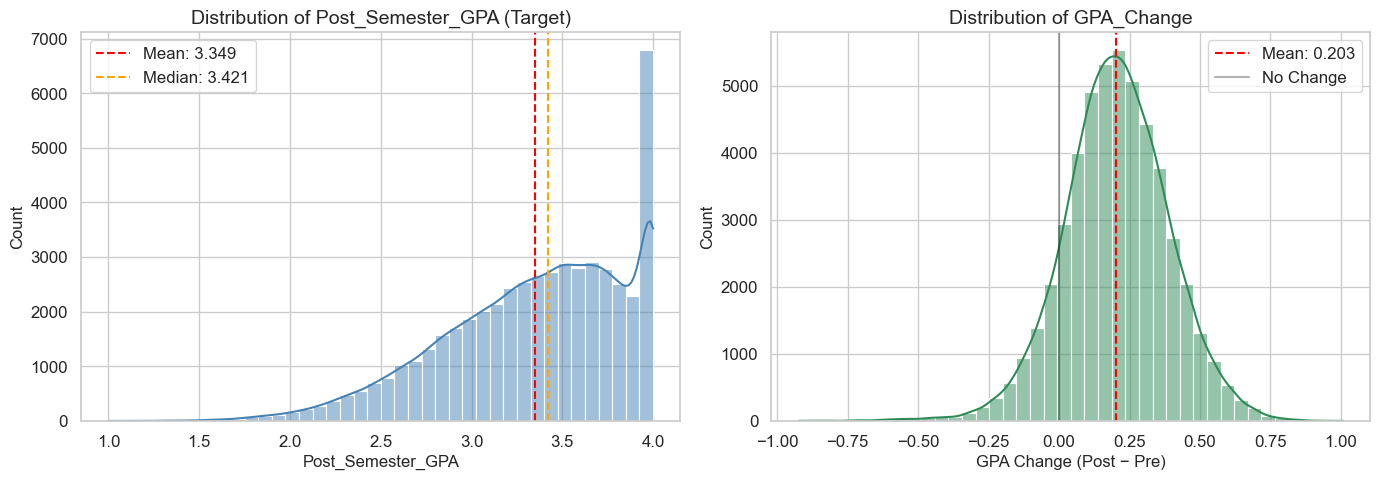

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 5a – Distribution of Post_Semester_GPA
sns.histplot(df["Post_Semester_GPA"], bins=40, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Distribution of Post_Semester_GPA (Target)")
axes[0].set_xlabel("Post_Semester_GPA")
axes[0].set_ylabel("Count")
axes[0].axvline(df["Post_Semester_GPA"].mean(), color="red", ls="--", label=f'Mean: {df["Post_Semester_GPA"].mean():.3f}')
axes[0].axvline(df["Post_Semester_GPA"].median(), color="orange", ls="--", label=f'Median: {df["Post_Semester_GPA"].median():.3f}')
axes[0].legend()

# 5b – Distribution of GPA_Change
sns.histplot(df["GPA_Change"], bins=40, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Distribution of GPA_Change")
axes[1].set_xlabel("GPA Change (Post − Pre)")
axes[1].set_ylabel("Count")
axes[1].axvline(df["GPA_Change"].mean(), color="red", ls="--", label=f'Mean: {df["GPA_Change"].mean():.3f}')
axes[1].axvline(0, color="black", ls="-", alpha=0.3, label="No Change")
axes[1].legend()

plt.tight_layout()
plt.show()

In [14]:
# GPA change direction breakdown
positive = (df["GPA_Change"] > 0).mean() * 100
negative = (df["GPA_Change"] < 0).mean() * 100
no_change = (df["GPA_Change"] == 0).mean() * 100

print("── GPA Change Direction ──")
print(f"  Students with GPA increase : {positive:.2f}%")
print(f"  Students with GPA decrease : {negative:.2f}%")
print(f"  Students with no change    : {no_change:.2f}%")
print(f"\n  Mean GPA change  : {df['GPA_Change'].mean():.3f}")
print(f"  Median GPA change: {df['GPA_Change'].median():.3f}")

── GPA Change Direction ──
  Students with GPA increase : 87.52%
  Students with GPA decrease : 12.38%
  Students with no change    : 0.10%

  Mean GPA change  : 0.203
  Median GPA change: 0.204


### Key Findings — Target Variable

- **`Post_Semester_GPA`** is slightly left-skewed, with most students clustering in the 3.0–4.0 range.
- The **mean GPA change is positive** (~0.20), indicating that the majority of students improved their GPA over the semester.
- Approximately **87–88% of students** experienced a GPA increase, while only ~12% declined.
- The distribution is roughly continuous, confirming that **regression** is the appropriate modeling approach for this target.

---
## 6. Feature Distribution Analysis

We examine the distributions of both continuous and categorical features to understand their shapes, spreads, and potential modeling implications.

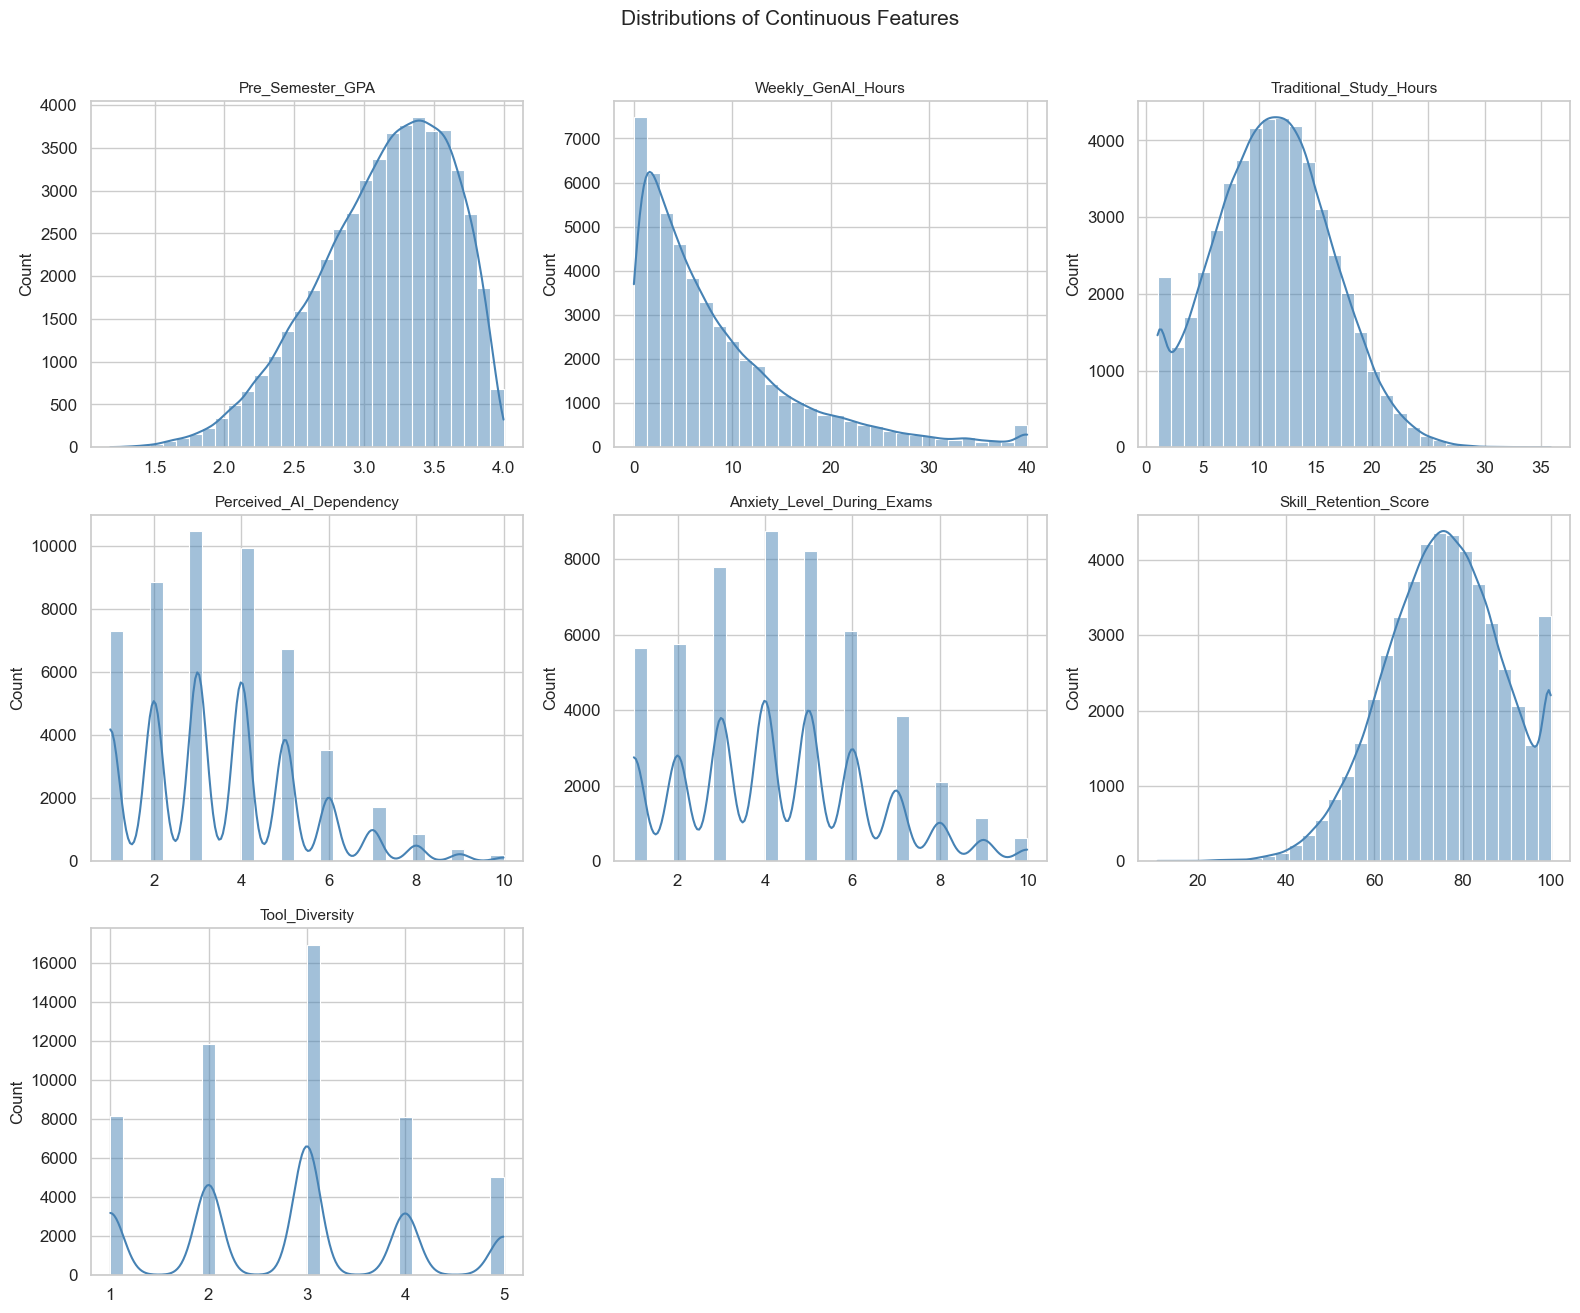

In [15]:
# 6a – Continuous feature distributions
continuous_features = [
    "Pre_Semester_GPA", "Weekly_GenAI_Hours", "Traditional_Study_Hours",
    "Perceived_AI_Dependency", "Anxiety_Level_During_Exams",
    "Skill_Retention_Score", "Tool_Diversity"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Hide unused subplots
for j in range(len(continuous_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Continuous Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

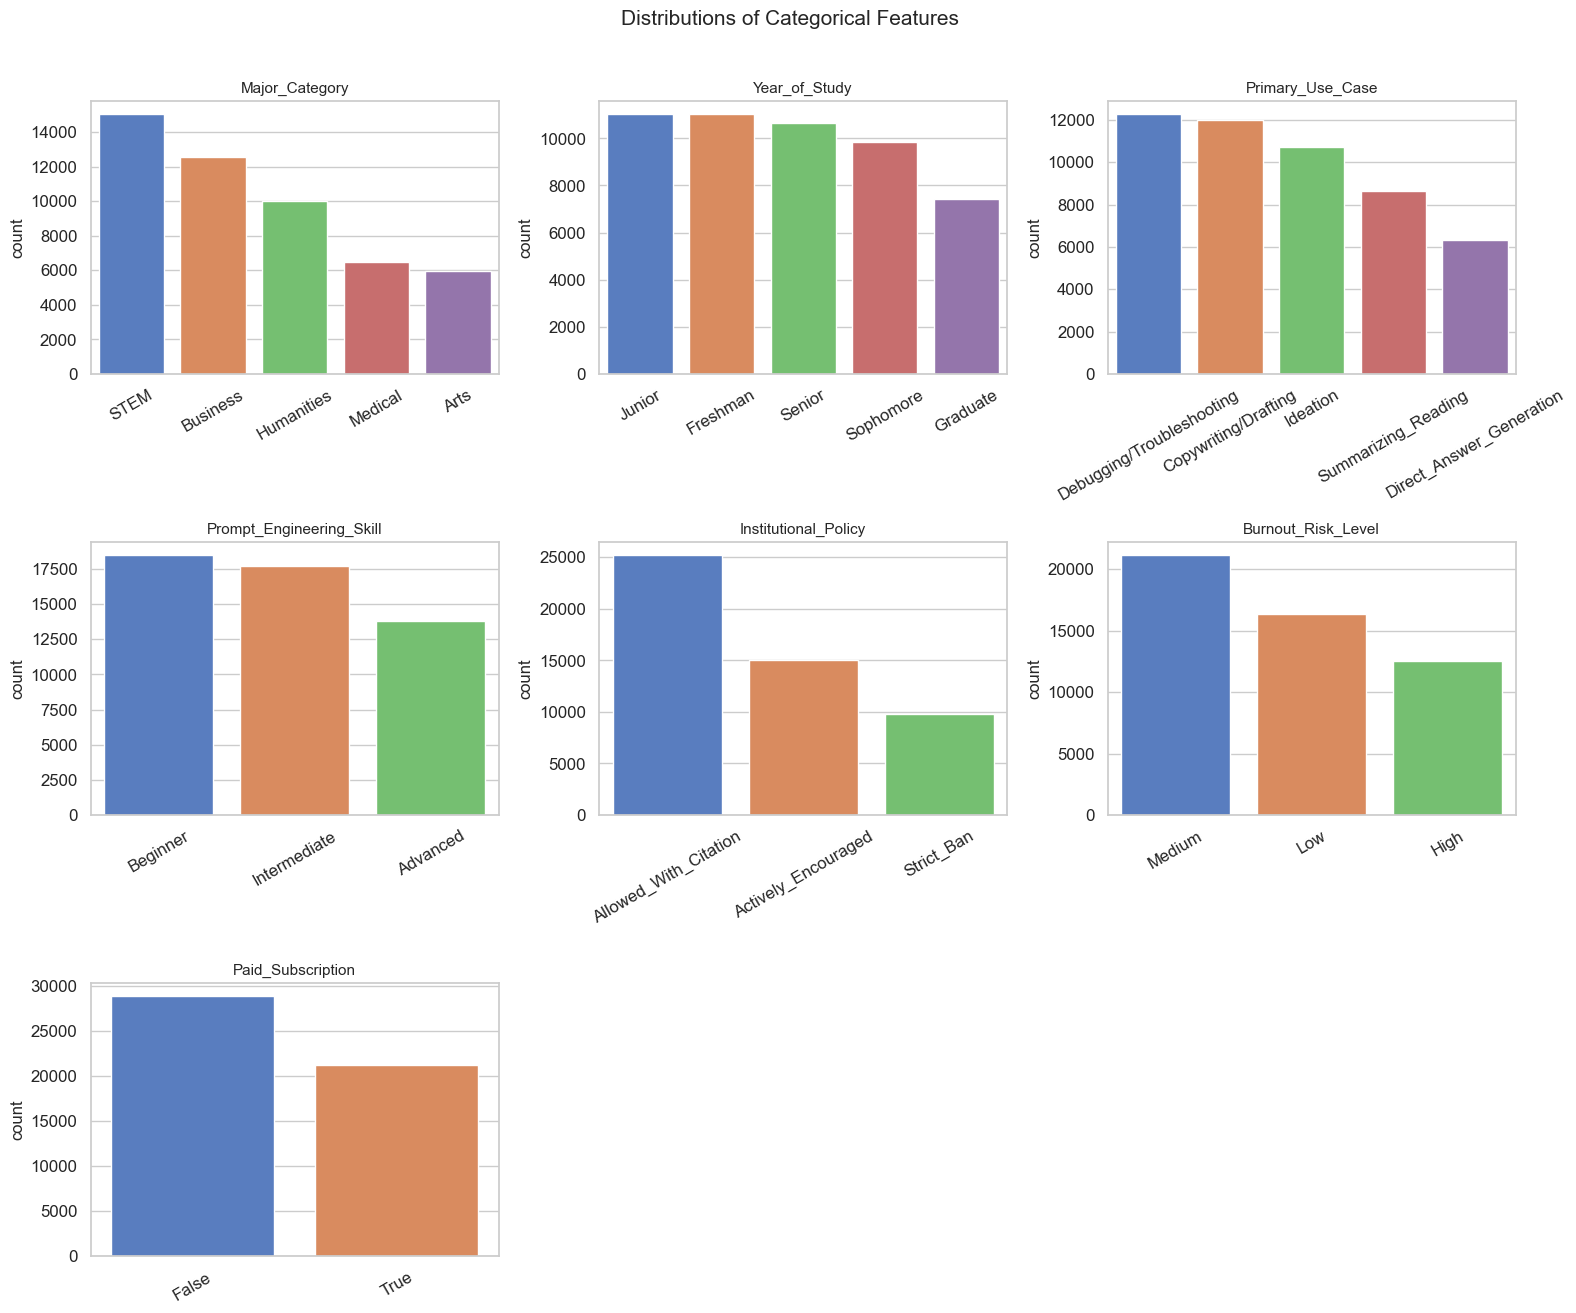

In [16]:
# 6b – Categorical feature distributions
categorical_features = [
    "Major_Category", "Year_of_Study", "Primary_Use_Case",
    "Prompt_Engineering_Skill", "Institutional_Policy",
    "Burnout_Risk_Level", "Paid_Subscription"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette="muted")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(categorical_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Categorical Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Key Findings — Feature Distributions

- **`Weekly_GenAI_Hours`** is right-skewed — most students use GenAI tools for fewer than 10 hours/week, but a long tail extends to 40 hours.
- **`Traditional_Study_Hours`** follows a roughly normal distribution centered around 11 hours/week.
- **`Perceived_AI_Dependency`** and **`Anxiety_Level_During_Exams`** are discrete integer scales (1–10) and are right-skewed.
- **`Pre_Semester_GPA`** is left-skewed, meaning most students start with relatively high GPAs.
- Categorical features are **approximately balanced** — no single category overwhelmingly dominates.

**Modeling implication:** Some features may benefit from log transformation or binning to reduce skewness.

---
## 7. GenAI Usage Behavior Analysis

This section examines how GenAI usage patterns — including hours, use cases, prompt engineering skill, and subscriptions — are associated with academic performance.

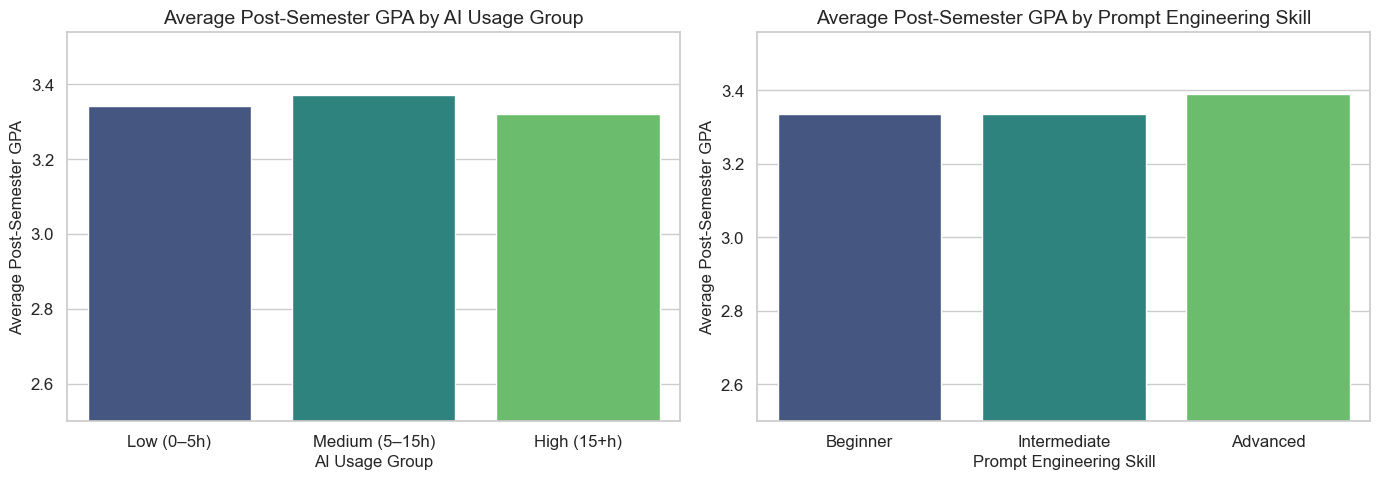

In [17]:
# 7a – Average Post_Semester_GPA by AI_Usage_Group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_group_gpa = df.groupby("AI_Usage_Group", observed=True)["Post_Semester_GPA"].mean().reset_index()
ai_group_gpa.columns = ["AI_Usage_Group", "Avg_Post_GPA"]

sns.barplot(data=ai_group_gpa, x="AI_Usage_Group", y="Avg_Post_GPA",
            palette="viridis", ax=axes[0])
axes[0].set_title("Average Post-Semester GPA by AI Usage Group")
axes[0].set_xlabel("AI Usage Group")
axes[0].set_ylabel("Average Post-Semester GPA")
axes[0].set_ylim(bottom=2.5)

# 7b – Average Post_Semester_GPA by Prompt_Engineering_Skill
skill_order = ["Beginner", "Intermediate", "Advanced"]
skill_gpa = df.groupby("Prompt_Engineering_Skill")["Post_Semester_GPA"].mean().reindex(skill_order).reset_index()
skill_gpa.columns = ["Prompt_Engineering_Skill", "Avg_Post_GPA"]

sns.barplot(data=skill_gpa, x="Prompt_Engineering_Skill", y="Avg_Post_GPA",
            palette="viridis", order=skill_order, ax=axes[1])
axes[1].set_title("Average Post-Semester GPA by Prompt Engineering Skill")
axes[1].set_xlabel("Prompt Engineering Skill")
axes[1].set_ylabel("Average Post-Semester GPA")
axes[1].set_ylim(bottom=2.5)

plt.tight_layout()
plt.show()

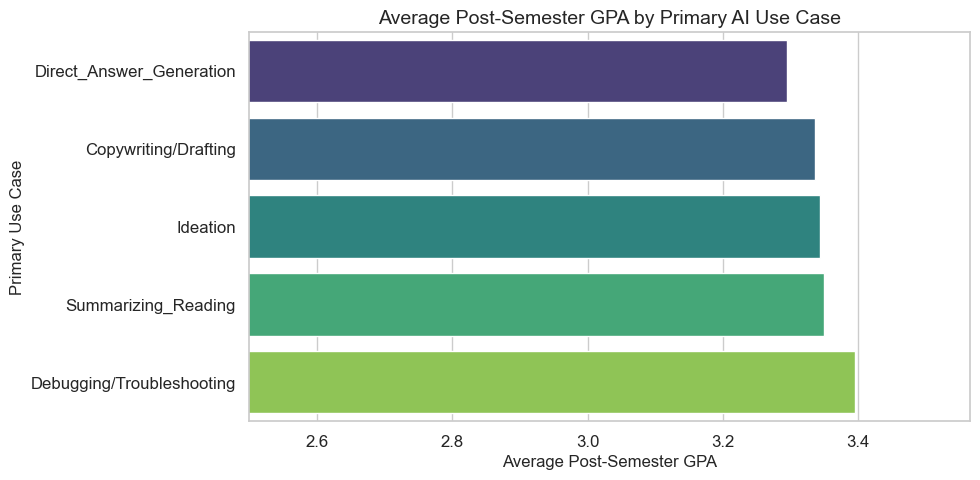

In [18]:
# 7c – Average Post_Semester_GPA by Primary Use Case
use_case_gpa = df.groupby("Primary_Use_Case")["Post_Semester_GPA"].mean().sort_values(ascending=True).reset_index()
use_case_gpa.columns = ["Primary_Use_Case", "Avg_Post_GPA"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=use_case_gpa, y="Primary_Use_Case", x="Avg_Post_GPA",
            palette="viridis", ax=ax)
ax.set_title("Average Post-Semester GPA by Primary AI Use Case")
ax.set_xlabel("Average Post-Semester GPA")
ax.set_ylabel("Primary Use Case")
ax.set_xlim(left=2.5)
plt.tight_layout()
plt.show()

In [19]:
# 7d – Paid subscription impact
sub_gpa = df.groupby("Paid_Subscription").agg(
    students=("Student_ID", "count"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
).reset_index()

print("── Paid Subscription Analysis ──")
print(sub_gpa.to_string(index=False))
sub_gap = abs(sub_gpa["avg_gpa_change"].diff().dropna().values[0])
print(f"\nGPA change gap between subscription groups: {sub_gap:.3f}")

── Paid Subscription Analysis ──
 Paid_Subscription  students  avg_post_gpa  avg_gpa_change  avg_genai_hours
             False     28846         3.347           0.200            7.033
              True     21154         3.352           0.207           10.330

GPA change gap between subscription groups: 0.007


### Key Findings — GenAI Usage

- **AI usage intensity** shows only modest differences in average Post-Semester GPA across Low, Medium, and High usage groups. This suggests that the *amount* of GenAI usage alone does not strongly predict GPA.
- **Prompt engineering skill** appears to be associated with slightly different GPA outcomes, though differences are small.
- **Primary use case** analysis reveals minor variations — different AI applications may have marginally different associations with academic performance.
- **Paid subscriptions** show a negligible GPA gap, suggesting that paid tool access alone does not guarantee better academic outcomes.

> **Caution:** These associations do not necessarily imply causation. Students who use AI more or less may differ in other important ways.

---
## 8. Academic Performance Analysis

We explore how prior academic performance, year of study, and major category are associated with the target variable.

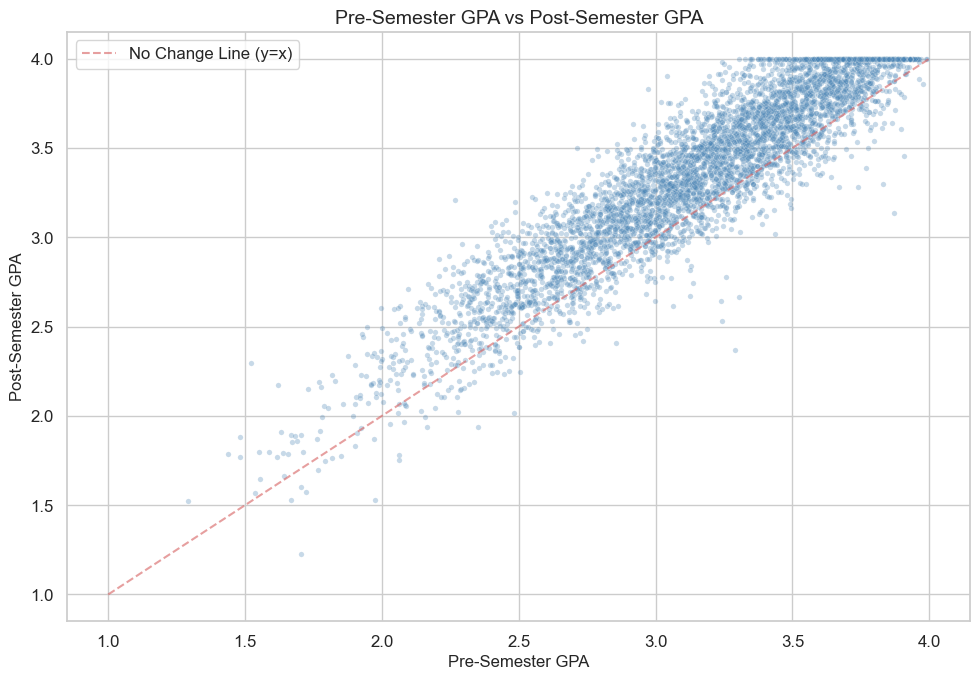

Pearson correlation (Pre vs Post GPA): r = 0.9268


In [20]:
# 8a – Pre_Semester_GPA vs Post_Semester_GPA (scatter)
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=df.sample(5000, random_state=42),
                x="Pre_Semester_GPA", y="Post_Semester_GPA",
                alpha=0.3, s=15, color="steelblue", ax=ax)

# Perfect parity line
ax.plot([1, 4], [1, 4], "r--", alpha=0.6, label="No Change Line (y=x)")
ax.set_title("Pre-Semester GPA vs Post-Semester GPA")
ax.set_xlabel("Pre-Semester GPA")
ax.set_ylabel("Post-Semester GPA")
ax.legend()
plt.tight_layout()
plt.show()

r = df["Pre_Semester_GPA"].corr(df["Post_Semester_GPA"])
print(f"Pearson correlation (Pre vs Post GPA): r = {r:.4f}")

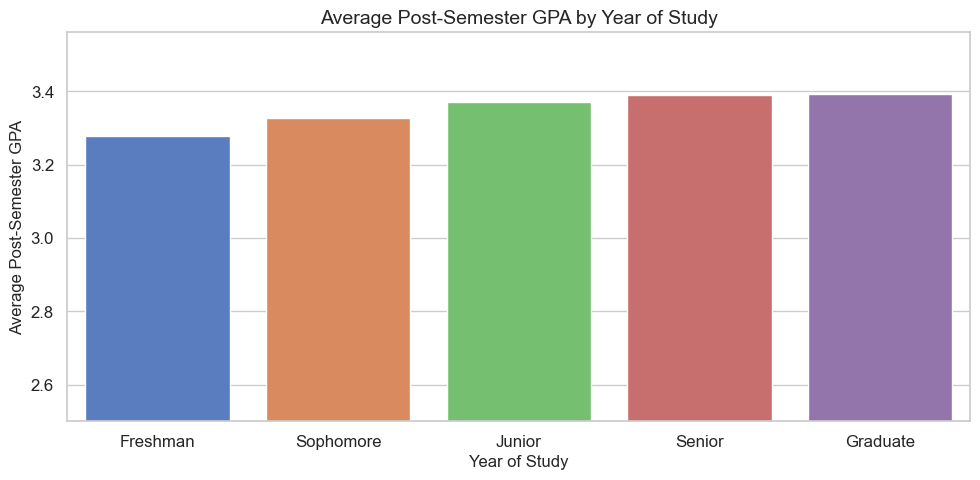

In [21]:
# 8b – Average Post_Semester_GPA by Year_of_Study
year_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
year_gpa = df.groupby("Year_of_Study")["Post_Semester_GPA"].mean().reindex(year_order).reset_index()
year_gpa.columns = ["Year_of_Study", "Avg_Post_GPA"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=year_gpa, x="Year_of_Study", y="Avg_Post_GPA",
            palette="muted", order=year_order, ax=ax)
ax.set_title("Average Post-Semester GPA by Year of Study")
ax.set_xlabel("Year of Study")
ax.set_ylabel("Average Post-Semester GPA")
ax.set_ylim(bottom=2.5)
plt.tight_layout()
plt.show()

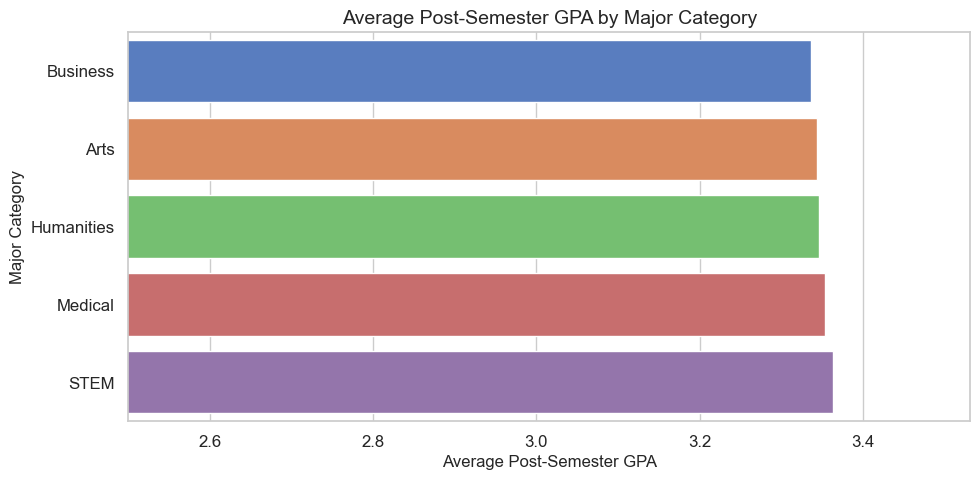

In [22]:
# 8c – Average Post_Semester_GPA by Major_Category
major_gpa = df.groupby("Major_Category")["Post_Semester_GPA"].mean().sort_values(ascending=True).reset_index()
major_gpa.columns = ["Major_Category", "Avg_Post_GPA"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=major_gpa, y="Major_Category", x="Avg_Post_GPA",
            palette="muted", ax=ax)
ax.set_title("Average Post-Semester GPA by Major Category")
ax.set_xlabel("Average Post-Semester GPA")
ax.set_ylabel("Major Category")
ax.set_xlim(left=2.5)
plt.tight_layout()
plt.show()

### Key Findings — Academic Performance

- **`Pre_Semester_GPA` is strongly correlated with `Post_Semester_GPA`** — the scatter plot shows a clear positive linear trend, and most data points sit above the parity line (indicating GPA improvement).
- This strong correlation suggests that `Pre_Semester_GPA` will likely be the **single most important predictor** in any regression model.
- **Year of Study** and **Major Category** show only small differences in average Post-Semester GPA, suggesting they may have limited predictive power on their own.

**Modeling implication:** Because `Pre_Semester_GPA` dominates the prediction, two experiments should be conducted — one with and one without this feature — to assess how well other features predict GPA independently.

---
## 9. Study Behavior Analysis

We analyze the relationship between study habits (both traditional and GenAI-assisted), AI dependency, and institutional policies with GPA outcomes.

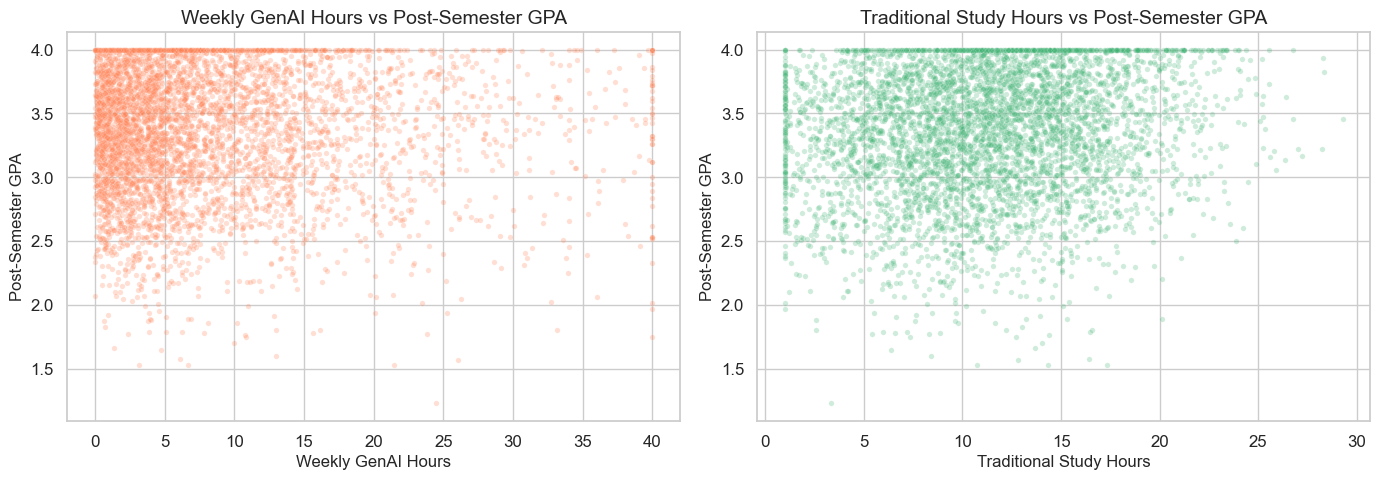

Correlation (GenAI Hours vs Post GPA)       : r = -0.0186
Correlation (Traditional Hours vs Post GPA)  : r = 0.1377


In [23]:
# 9a – Weekly_GenAI_Hours vs Post_Semester_GPA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df.sample(5000, random_state=42),
                x="Weekly_GenAI_Hours", y="Post_Semester_GPA",
                alpha=0.25, s=15, color="coral", ax=axes[0])
axes[0].set_title("Weekly GenAI Hours vs Post-Semester GPA")
axes[0].set_xlabel("Weekly GenAI Hours")
axes[0].set_ylabel("Post-Semester GPA")

# 9b – Traditional_Study_Hours vs Post_Semester_GPA
sns.scatterplot(data=df.sample(5000, random_state=42),
                x="Traditional_Study_Hours", y="Post_Semester_GPA",
                alpha=0.25, s=15, color="mediumseagreen", ax=axes[1])
axes[1].set_title("Traditional Study Hours vs Post-Semester GPA")
axes[1].set_xlabel("Traditional Study Hours")
axes[1].set_ylabel("Post-Semester GPA")

plt.tight_layout()
plt.show()

r_genai = df["Weekly_GenAI_Hours"].corr(df["Post_Semester_GPA"])
r_trad  = df["Traditional_Study_Hours"].corr(df["Post_Semester_GPA"])
print(f"Correlation (GenAI Hours vs Post GPA)       : r = {r_genai:.4f}")
print(f"Correlation (Traditional Hours vs Post GPA)  : r = {r_trad:.4f}")

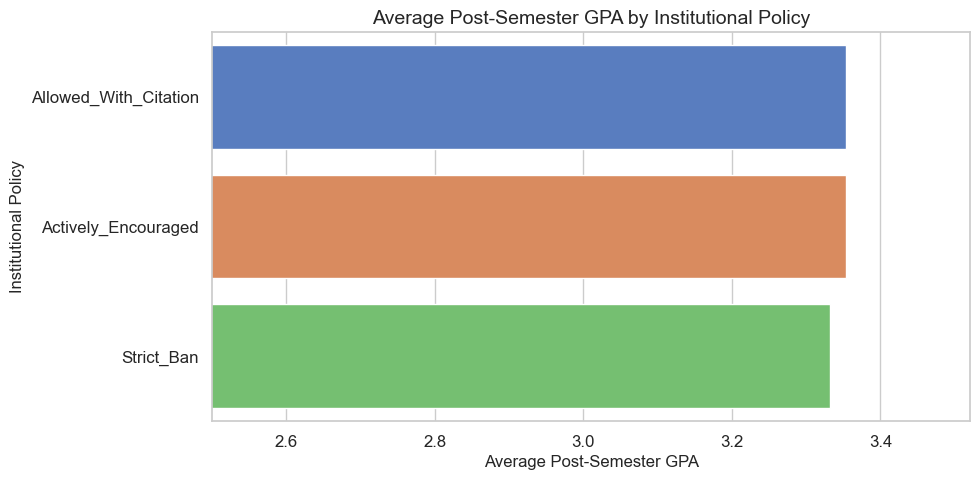

── Institutional Policy Details ──
 Institutional_Policy  students  avg_post_gpa  avg_gpa_change  avg_genai_hours  avg_dependency
Allowed_With_Citation     25224         3.353           0.208            8.420           3.505
  Actively_Encouraged     14988         3.353           0.206            8.478           3.519
           Strict_Ban      9788         3.333           0.187            8.370           3.484


In [24]:
# 9c – Institutional policy impact
policy_gpa = df.groupby("Institutional_Policy").agg(
    students=("Student_ID", "count"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
).sort_values("avg_gpa_change", ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=policy_gpa, y="Institutional_Policy", x="avg_post_gpa",
            palette="muted", ax=ax)
ax.set_title("Average Post-Semester GPA by Institutional Policy")
ax.set_xlabel("Average Post-Semester GPA")
ax.set_ylabel("Institutional Policy")
ax.set_xlim(left=2.5)
plt.tight_layout()
plt.show()

print("── Institutional Policy Details ──")
print(policy_gpa.to_string(index=False))

### Key Findings — Study Behavior

- Both **Weekly GenAI Hours** and **Traditional Study Hours** show weak linear correlations with Post-Semester GPA, suggesting that the relationship between study time and GPA is not simply linear.
- **Institutional AI policy** (Strict Ban, Allowed With Citation, No Clear Policy) shows only marginal differences in average GPA, indicating that policy type alone may not significantly impact academic outcomes.
- The weak individual correlations suggest that these features may be more useful in **combination** (e.g., interaction terms) rather than individually.

---
## 10. Burnout & Anxiety Analysis

We investigate whether burnout risk and exam anxiety levels are associated with academic performance.

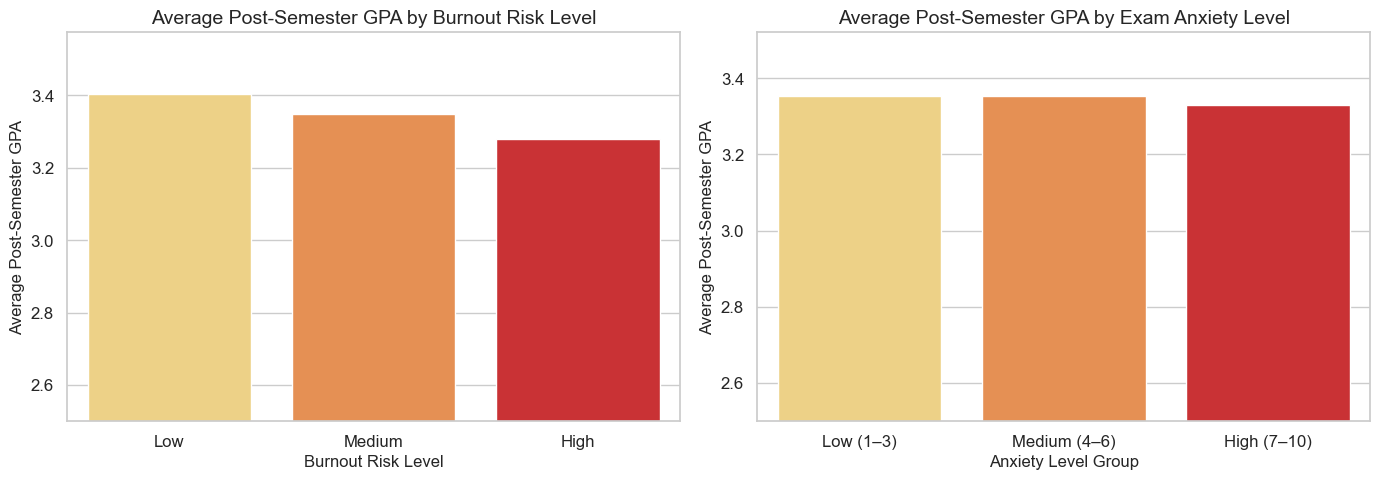

In [25]:
# 10a – Average Post_Semester_GPA by Burnout_Risk_Level
burnout_order = ["Low", "Medium", "High"]
burnout_gpa = df.groupby("Burnout_Risk_Level")["Post_Semester_GPA"].mean().reindex(burnout_order).reset_index()
burnout_gpa.columns = ["Burnout_Risk_Level", "Avg_Post_GPA"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=burnout_gpa, x="Burnout_Risk_Level", y="Avg_Post_GPA",
            palette="YlOrRd", order=burnout_order, ax=axes[0])
axes[0].set_title("Average Post-Semester GPA by Burnout Risk Level")
axes[0].set_xlabel("Burnout Risk Level")
axes[0].set_ylabel("Average Post-Semester GPA")
axes[0].set_ylim(bottom=2.5)

# 10b – GPA distribution by anxiety level (binned)
anxiety_bins = pd.cut(df["Anxiety_Level_During_Exams"], bins=[0, 3, 6, 10],
                      labels=["Low (1–3)", "Medium (4–6)", "High (7–10)"])
anxiety_gpa = df.groupby(anxiety_bins, observed=True)["Post_Semester_GPA"].mean().reset_index()
anxiety_gpa.columns = ["Anxiety_Group", "Avg_Post_GPA"]

sns.barplot(data=anxiety_gpa, x="Anxiety_Group", y="Avg_Post_GPA",
            palette="YlOrRd", ax=axes[1])
axes[1].set_title("Average Post-Semester GPA by Exam Anxiety Level")
axes[1].set_xlabel("Anxiety Level Group")
axes[1].set_ylabel("Average Post-Semester GPA")
axes[1].set_ylim(bottom=2.5)

plt.tight_layout()
plt.show()

In [26]:
# 10c – Detailed burnout analysis table
burnout_detail = df.groupby("Burnout_Risk_Level").agg(
    students=("Student_ID", "count"),
    avg_post_gpa=("Post_Semester_GPA", "mean"),
    avg_gpa_change=("GPA_Change", "mean"),
    avg_genai_hours=("Weekly_GenAI_Hours", "mean"),
    avg_dependency=("Perceived_AI_Dependency", "mean"),
    avg_anxiety=("Anxiety_Level_During_Exams", "mean"),
    avg_skill_retention=("Skill_Retention_Score", "mean"),
).reindex(burnout_order).reset_index()

print("── Burnout Risk Level Details ──")
print(burnout_detail.to_string(index=False))

── Burnout Risk Level Details ──
Burnout_Risk_Level  students  avg_post_gpa  avg_gpa_change  avg_genai_hours  avg_dependency  avg_anxiety  avg_skill_retention
               Low     16369         3.405           0.200            4.644           2.820        3.928               76.402
            Medium     21144         3.348           0.210            7.349           3.365        4.170               76.243
              High     12487         3.278           0.196           15.215           4.642        4.889               74.253


### Key Findings — Burnout & Anxiety

- **Higher burnout risk** appears to be associated with slightly lower Post-Semester GPA, though the magnitude of the difference is modest.
- Students with **higher exam anxiety** also tend to show marginally lower GPA outcomes.
- These associations do not necessarily imply causation — students experiencing academic difficulties may also report higher burnout and anxiety.

**Modeling implication:** `Burnout_Risk_Level` and `Anxiety_Level_During_Exams` may serve as useful features, capturing psychological factors that other variables do not.

---
## 11. Correlation Analysis

A correlation heatmap helps identify which numeric features are linearly associated with each other and with the target variable.

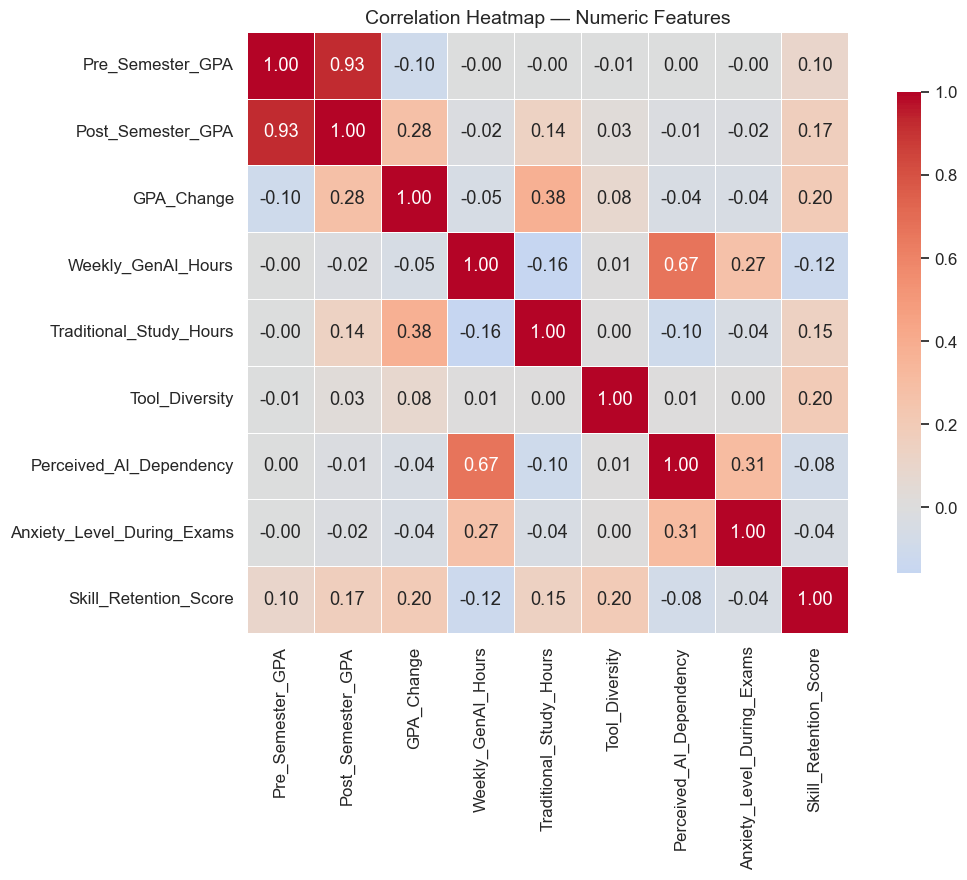

In [27]:
correlation_cols = [
    "Pre_Semester_GPA", "Post_Semester_GPA", "GPA_Change",
    "Weekly_GenAI_Hours", "Traditional_Study_Hours",
    "Tool_Diversity", "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams", "Skill_Retention_Score"
]

corr_matrix = df[correlation_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap — Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# Correlation with the target variable
target_corr = corr_matrix["Post_Semester_GPA"].drop("Post_Semester_GPA").sort_values(ascending=False)
print("── Correlation with Post_Semester_GPA ──")
for feat, r in target_corr.items():
    bar = "█" * int(abs(r) * 40)
    sign = "+" if r > 0 else "−"
    print(f"  {sign} {feat:30s} : {r:+.4f}  {bar}")

── Correlation with Post_Semester_GPA ──
  + Pre_Semester_GPA               : +0.9268  █████████████████████████████████████
  + GPA_Change                     : +0.2771  ███████████
  + Skill_Retention_Score          : +0.1696  ██████
  + Traditional_Study_Hours        : +0.1377  █████
  + Tool_Diversity                 : +0.0253  █
  − Perceived_AI_Dependency        : -0.0142  
  − Anxiety_Level_During_Exams     : -0.0159  
  − Weekly_GenAI_Hours             : -0.0186  


### Key Findings — Correlation Analysis

- **`Pre_Semester_GPA`** has the strongest positive correlation with `Post_Semester_GPA`, confirming it as the dominant predictor.
- **`GPA_Change`** is mechanically correlated (it is derived from the target), so it must **not** be used as a feature during modeling.
- Other features show relatively weak individual correlations with the target, suggesting that:
  - No single non-GPA feature is a strong standalone predictor.
  - A multivariate model combining multiple features may be needed.
- **Multicollinearity** between features appears low, which is favorable for linear models.

> **Important:** Correlation measures only *linear* associations. Non-linear relationships may exist but are not captured here.

---
## 12. Feature–Target Relationship Analysis

We use box plots and violin plots to examine how the target variable (`Post_Semester_GPA`) varies across key categorical groups.

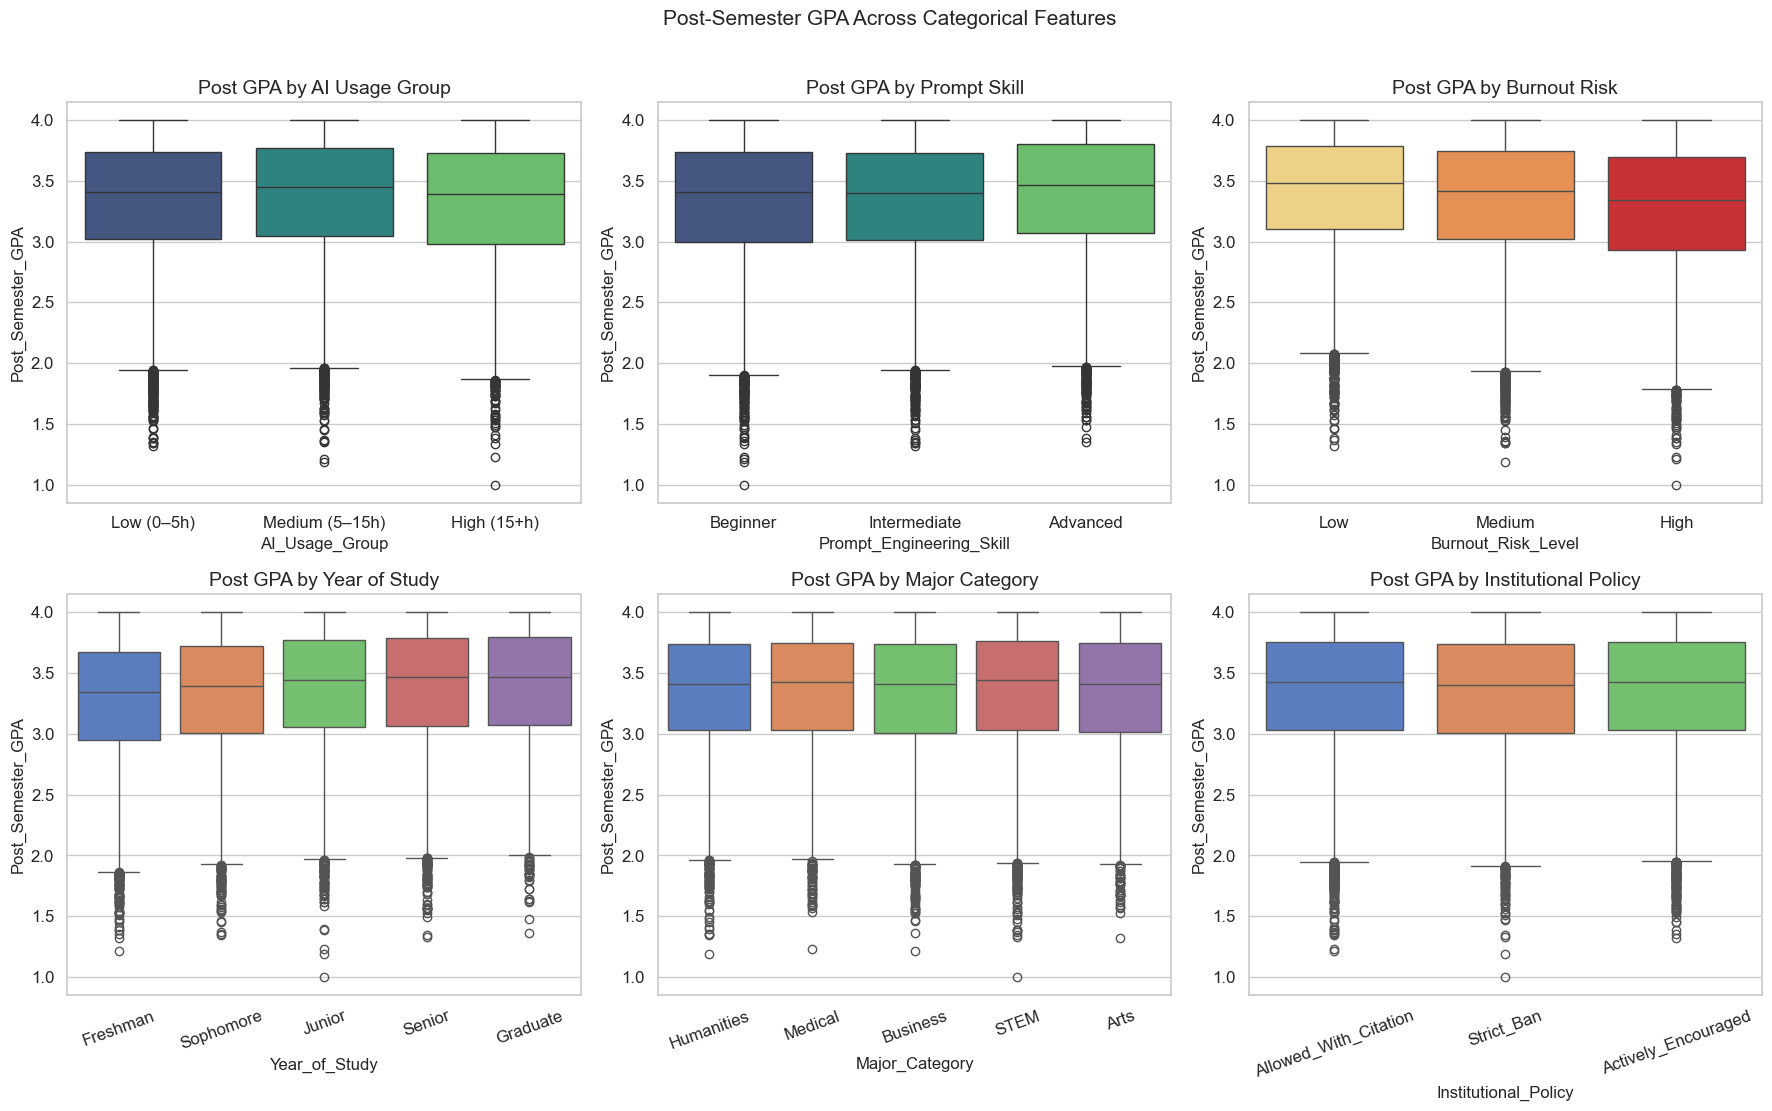

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 1
sns.boxplot(data=df, x="AI_Usage_Group", y="Post_Semester_GPA",
            palette="viridis", ax=axes[0, 0], order=ai_labels)
axes[0, 0].set_title("Post GPA by AI Usage Group")

sns.boxplot(data=df, x="Prompt_Engineering_Skill", y="Post_Semester_GPA",
            palette="viridis", ax=axes[0, 1], order=skill_order)
axes[0, 1].set_title("Post GPA by Prompt Skill")

sns.boxplot(data=df, x="Burnout_Risk_Level", y="Post_Semester_GPA",
            palette="YlOrRd", ax=axes[0, 2], order=burnout_order)
axes[0, 2].set_title("Post GPA by Burnout Risk")

# Row 2
sns.boxplot(data=df, x="Year_of_Study", y="Post_Semester_GPA",
            palette="muted", ax=axes[1, 0], order=year_order)
axes[1, 0].set_title("Post GPA by Year of Study")
axes[1, 0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Major_Category", y="Post_Semester_GPA",
            palette="muted", ax=axes[1, 1])
axes[1, 1].set_title("Post GPA by Major Category")
axes[1, 1].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Institutional_Policy", y="Post_Semester_GPA",
            palette="muted", ax=axes[1, 2])
axes[1, 2].set_title("Post GPA by Institutional Policy")
axes[1, 2].tick_params(axis="x", rotation=20)

plt.suptitle("Post-Semester GPA Across Categorical Features", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Key Findings — Feature–Target Relationships

- The box plots confirm that while group-level means show some variation, the **distributions heavily overlap** across most categorical features.
- This suggests that individual categorical features provide limited discriminative power on their own, reinforcing the need for a **multivariate modeling approach**.
- `Pre_Semester_GPA` (continuous, strong correlation) is likely to dominate prediction accuracy, while categorical features may provide incremental improvements.

---
## 13. EDA Findings for Modeling

This section summarizes the key takeaways from the exploratory analysis that directly inform the modeling strategy in `02_modeling.ipynb`.

### Why `Post_Semester_GPA` is a Regression Target

- The target variable is **continuous** (range: 1.0–4.0) with a roughly normal distribution.
- **Regression** (not classification) is the appropriate problem framing.

### Why `Student_ID` Should Be Dropped

- `Student_ID` is a unique identifier with no predictive value — it carries no information about GPA.
- Including it would introduce noise or cause the model to memorize individual records (overfitting).

### Why Categorical Variables Need Encoding

- Features like `Major_Category`, `Year_of_Study`, `Primary_Use_Case`, `Prompt_Engineering_Skill`, `Institutional_Policy`, and `Burnout_Risk_Level` are stored as strings.
- Machine learning models require numeric inputs, so these must be encoded (e.g., one-hot encoding or ordinal encoding).

### Why `Pre_Semester_GPA` is Expected to Be the Strongest Predictor

- The correlation analysis shows that `Pre_Semester_GPA` has the **highest linear correlation** with `Post_Semester_GPA`.
- The scatter plot confirms a strong positive linear relationship.
- This is expected — a student's prior GPA is the best single indicator of their future GPA.

### Why Two Modeling Experiments Should Be Conducted

1. **With `Pre_Semester_GPA`:** This will produce the most accurate predictions but may mask the contribution of other features, since prior GPA dominates.
2. **Without `Pre_Semester_GPA`:** This tests whether GenAI usage, study habits, and psychological factors can predict GPA independently — a more interesting and actionable research question.

### Which Features Are Likely Useful for Modeling

| Feature | Type | Expected Usefulness |
|---|---|---|
| `Pre_Semester_GPA` | Continuous | Very High — dominant predictor |
| `Skill_Retention_Score` | Continuous | Moderate — correlated with outcomes |
| `Weekly_GenAI_Hours` | Continuous | Low-Moderate — weak individual correlation |
| `Traditional_Study_Hours` | Continuous | Low-Moderate |
| `Perceived_AI_Dependency` | Ordinal (1–10) | Low-Moderate |
| `Anxiety_Level_During_Exams` | Ordinal (1–10) | Low-Moderate |
| `Tool_Diversity` | Ordinal (1–5) | Low |
| `Prompt_Engineering_Skill` | Categorical | Low — small group differences |
| `Major_Category` | Categorical | Low |
| `Year_of_Study` | Categorical | Low |
| `Primary_Use_Case` | Categorical | Low |
| `Burnout_Risk_Level` | Categorical | Low-Moderate |
| `Institutional_Policy` | Categorical | Low |
| `Paid_Subscription` | Boolean | Very Low — negligible effect observed |

### Potential Limitations of the Dataset

- **Observational data:** All relationships are correlational — no causal claims can be made.
- **Self-reported features:** Variables like `Perceived_AI_Dependency` and `Anxiety_Level_During_Exams` are subjective and may contain measurement noise.
- **Synthetic/simulated appearance:** The dataset has zero missing values, no outliers, and perfectly balanced categories — this is unusual for real-world data and may limit generalizability.
- **No temporal dimension:** A single semester snapshot does not capture longitudinal trends.
- **Feature leakage risk:** `Skill_Retention_Score` and `Burnout_Risk_Level` may be measured at or after the same time as the target, raising potential leakage concerns.

---
## 14. EDA Conclusion

### Summary of Key Findings

1. **The dataset is clean and complete** — no missing values, duplicates, or structural issues were found.
2. **`Post_Semester_GPA` is an appropriate regression target** with a roughly normal distribution.
3. **~88% of students improved their GPA** over the semester, with a mean increase of approximately 0.20 points.
4. **`Pre_Semester_GPA` is the strongest single predictor** of `Post_Semester_GPA`, with a high positive correlation.
5. **GenAI usage patterns** (hours, use cases, prompt skill) show only modest associations with GPA outcomes, suggesting that the *way* AI is used may matter more than how *much* it is used.
6. **Burnout and anxiety** appear to be weakly associated with lower GPA, but the effect sizes are small.
7. **Most individual features have weak standalone predictive power**, reinforcing the need for multivariate models that capture feature interactions.

### Data Readiness Assessment

| Criterion | Status |
|---|---|
| No missing values | ✓ |
| No duplicate records | ✓ |
| Target variable identified and validated | ✓ |
| Feature types documented | ✓ |
| Derived features created for analysis | ✓ |
| Potential predictors identified | ✓ |
| Modeling strategy defined | ✓ |

**The dataset is ready for modeling.** Proceed to `02_modeling.ipynb` for feature engineering, model training, and evaluation.